In [1]:
# Importações básicas de manipulação e análise de dados
import unicodedata
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

# Baixar as stopwords em português do NLTK (executar apenas na primeira vez)
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Carregando a base de dados de reviews

In [2]:
df_reviews = pd.read_csv("olist_order_reviews_dataset.csv")

# Selecionar apenas as colunas relevantes
df_text = df_reviews[["review_score", "review_comment_message"]].copy()

# Remover linhas onde o comentário está vazio (NaN)
df_text = df_text.dropna(subset=["review_comment_message"])

print(f"Total de comentários válidos para análise: {len(df_text)}")
df_text.head()

Total de comentários válidos para análise: 40977


,review_score,review_comment_message
3,5,Recebi bem antes do prazo estipulado.
4,5,Parabéns lojas lannister adorei comprar pela I...
9,4,aparelho eficiente. no site a marca do aparelh...
12,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
15,5,"Vendedor confiável, produto ok e entrega antes..."


# Lista de stopwords em português do NLTK

In [3]:
stop_words_pt = set(stopwords.words("portuguese"))

# Adicionando palavras adicionais comuns em reviews que não agregam tema específico
custom_stop_words = {
    "produto",
    "chegou",
    "veio",
    "comprei",
    "dia",
    "muito",
    "tudo",
    "tb",
    "pra",
}
stop_words_pt.update(custom_stop_words)


def limpar_texto(texto):
    """Função para padronizar, remover acentos, pontuação e stopwords."""
    if not isinstance(texto, str):
        return ""

    # Convertendo para minúsculas
    texto = texto.lower()

    # Removendo acentos
    texto = (
        unicodedata.normalize("NFD", texto)
        .encode("ascii", "ignore")
        .decode("utf-8")
    )

    # Mantendo apenas letras
    texto = "".join([char if char.isalpha() else " " for char in texto])

    # Removendo stopwords
    palavras = texto.split()
    palavras_filtradas = [
        word for word in palavras if word not in stop_words_pt and len(word) > 2
    ]

    return " ".join(palavras_filtradas)


# Aplicando a limpeza nos comentários
df_text["texto_limpo"] = df_text["review_comment_message"].apply(limpar_texto)

# Filtrar registros que possam ter ficado vazios após a limpeza
df_text = df_text[df_text["texto_limpo"].str.strip() != ""]

df_text[["review_score", "review_comment_message", "texto_limpo"]].head(10)

,review_score,review_comment_message,texto_limpo
3,5,Recebi bem antes do prazo estipulado.,recebi bem antes prazo estipulado
4,5,Parabéns lojas lannister adorei comprar pela I...,parabens lojas lannister adorei comprar intern...
9,4,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente site marca aparelho impress...
12,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouco travando valor boa
15,5,"Vendedor confiável, produto ok e entrega antes...",vendedor confiavel entrega antes prazo
16,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",gostaria saber sempre recebi compra agora decp...
19,1,Péssimo,pessimo
22,5,Loja nota 10,loja nota
24,5,obrigado pela atençao amim dispensada,obrigado atencao amim dispensada
27,5,A compra foi realizada facilmente.\r\nA entreg...,compra realizada facilmente entrega efetuada a...


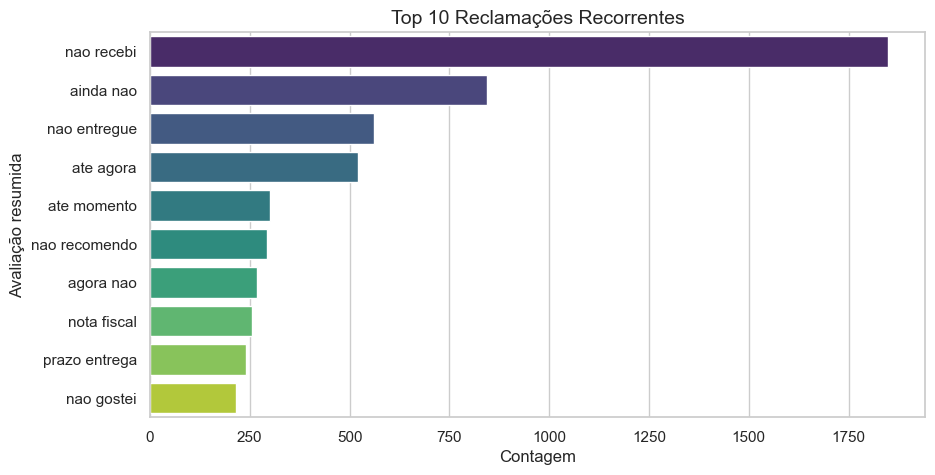

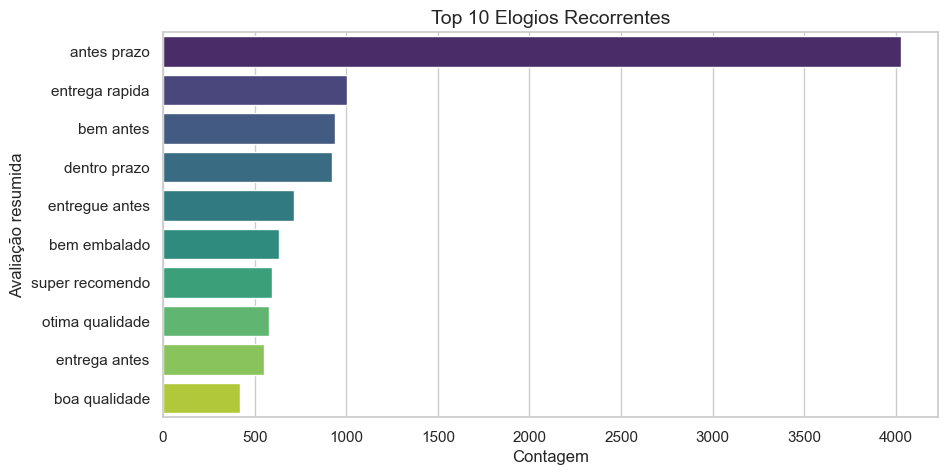

In [4]:
def plot_top_ngrams(text_series, title, n=2, top_k=10):
    """Calcula e plota os N-gramas mais frequentes."""
    vec = CountVectorizer(ngram_range=(n, n)).fit(text_series)
    bag_of_words = vec.transform(text_series)
    sum_words = bag_of_words.sum(axis=0)

    words_freq = [
        (word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()
    ]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    df_ngram = pd.DataFrame(words_freq, columns=["Bigrama", "Frequência"])

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x="Frequência",
        y="Bigrama",
        data=df_ngram,
        hue="Bigrama",
        palette="viridis",
        legend=False,
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Contagem")
    plt.ylabel("Avaliação resumida")
    plt.show()


# Bigramas em comentários negativos
plot_top_ngrams(
    df_text[df_text["review_score"] <= 2]["texto_limpo"],
    "Top 10 Reclamações Recorrentes",
)

# Bigramas em comentários positivos
plot_top_ngrams(
    df_text[df_text["review_score"] >= 4]["texto_limpo"],
    "Top 10 Elogios Recorrentes",
)